 loads the two CSV files

In [1]:
import csv
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 150)
pd.set_option("display.width", 200)

DATA_DIR = ""  # the CSV files sit next to this notebook

LABELS = {
    "Surgery", "Cardiovascular-Pulmonary", "Orthopedic", "Radiology",
    "General Medicine", "Gastroenterology", "Neurology", "Obstetrics-Gynecology",
    "Neurosurgery", "Ophthalmology", "Psychiatry-Psychology", "Dermatology",
}
TEXT_COLS = ["description", "sample_name", "transcription", "keywords"]
ALL_COLS = ["medical_specialty"] + TEXT_COLS

Loading the data



Both files use `;` as separator and `\r\n` between records, but they don't parse cleanly with a plain `pd.read_csv`.
In `train.csv`, a few records are cut off in the middle of a field (the line ends with `";;;`) and the rest of the
text continues on the next physical line. Here is one of them (line number, number of `"` on the line, start and end of the line):

In [2]:
with open(DATA_DIR + "train.csv", encoding="utf-8", newline="") as f:
    raw_lines = f.read().split("\r\n")

for i in range(957, 962):
    line = raw_lines[i]
    print(i + 1, line.count('"'), repr(line[:50]), "...", repr(line[-25:]))

958 0 'Radiology;OB Ultrasound - A 29-year-old female req' ... 'e, intrauterine gestation'
959 0 'Surgery; Recurrent anterior dislocating left shoul' ... ', shoulder, subscapularis'
960 0 'Cardiovascular-Pulmonary; Coronary artery bypass s' ... ', valve, stenosis, aortic'
961 1 'General Medicine;A 50-year-old white male with dog' ... 'o be viable.  The wou";;;'
962 0 'd is open about may be roughly a centimeter in the' ... ' several times a day.;;;;'


In [3]:
RECORD_START = re.compile(r"^(" + "|".join(map(re.escape, LABELS)) + r");")


def load_train(path):
    """Read train.csv and repair records that were split across lines.

    Returns the DataFrame and the indices of rows that still had unexpected extra fields.
    """
    with open(path, encoding="utf-8", newline="") as f:
        lines = f.read().split("\r\n")
    lines = [line for line in lines[1:] if line.strip()]  # skip header and blank lines

    # Glue truncated records back to their overflow line
    records = []
    for line in lines:
        is_continuation = records and records[-1].endswith('";;;') and not RECORD_START.match(line)
        if is_continuation:
            head = records.pop()[:-len('";;;')]
            line = head + line.lstrip('"').rstrip('";') + ";"  # keywords are lost, leave them empty
        records.append(line)

    # Parse each record on its own, so a stray quote can't swallow the next row
    rows, bad_rows = [], []
    for i, record in enumerate(records):
        fields = next(csv.reader([record], delimiter=";"))
        if any(f.strip() for f in fields[len(ALL_COLS):]):  # trailing extra fields should be empty
            bad_rows.append(i)
        fields = (fields + [""] * len(ALL_COLS))[:len(ALL_COLS)]
        rows.append([f.replace('""', '"').strip() for f in fields])

    df = pd.DataFrame(rows, columns=ALL_COLS).replace("", pd.NA)
    return df, bad_rows

The test file has no label column. Its problem is different: some fields contain a newline followed by text that belongs
to other fields. We keep only the part before the first newline.

In [4]:
def load_test(path):
    test = pd.read_csv(path, sep=";", header=None, names=TEXT_COLS)
    for col in TEXT_COLS:
        test[col] = test[col].str.split("\r\n").str[0].str.strip()
    return test

In [5]:
train, bad_rows = load_train(DATA_DIR + "train.csv")
test = load_test(DATA_DIR + "test_no_labels.csv")


def rows_with_newlines(df):
    has_newline = df[TEXT_COLS].apply(lambda col: col.astype(str).str.contains(r"[\r\n]"))
    return has_newline.any(axis=1).sum()


print("train:", train.shape, " test:", test.shape, " rows with extra fields:", bad_rows)
print("unknown labels:", (~train["medical_specialty"].isin(LABELS)).sum())
print("rows with newlines left:", rows_with_newlines(train), "(train),", rows_with_newlines(test), "(test)")

train: (2669, 5)  test: (409, 4)  rows with extra fields: []
unknown labels: 0
rows with newlines left: 0 (train), 0 (test)


In [6]:
only_description = train["sample_name"].isna() & train["transcription"].isna()
train.loc[only_description, ["medical_specialty", "description"]]

,medical_specialty,description
159,Cardiovascular-Pulmonary,"Seizure, hypoglycemia, anemia, dyspnea, edema. colon cancer status post right hemicolectomy, hospital-acquired pneumonia,"
712,General Medicine,"Seizure, hypoglycemia, anemia, dyspnea, edema. colon cancer status post right hemicolectomy, hospital-acquired pneumonia,"
945,Neurosurgery,"Anterior cervical discectomy, arthrodesis, partial corpectomy, Machine bone allograft, placement of anterior cervical plate with a Zephyr."
1085,Obstetrics-Gynecology,"D&C and hysteroscopy. Abnormal uterine bleeding, enlarged fibroid uterus, hypermenorrhea, intermenstrual spotting, and thickened endometrium per ultrasound of a 2 cm lining."
2086,Surgery,Tailor's bunionectomy with metatarsal osteotomy of the left fifth metatarsal. Excision of nerve lesion with implantation of the muscle belly of the left second interspace. Excision of nerve lesion in the left third interspace.
2325,Surgery,"Anterior cervical discectomy, arthrodesis, partial corpectomy, Machine bone allograft, placement of anterior cervical plate with a Zephyr."
2389,Surgery,"Liposuction of the supraumbilical abdomen, revision of right breast reconstruction, excision of soft tissue fullness of the lateral abdomen and flank."


data analysis


Class distribution

                          count     %
medical_specialty                    
Surgery                     893  33.5
Cardiovascular-Pulmonary    309  11.6
Orthopedic                  300  11.2
Radiology                   222   8.3
General Medicine            212   7.9
Gastroenterology            195   7.3
Neurology                   184   6.9
Obstetrics-Gynecology       136   5.1
Neurosurgery                 79   3.0
Ophthalmology                73   2.7
Psychiatry-Psychology        41   1.5
Dermatology                  25   0.9

imbalance ratio (largest / smallest): 893 / 25 = 35.7
accuracy of always predicting Surgery: 33.5%


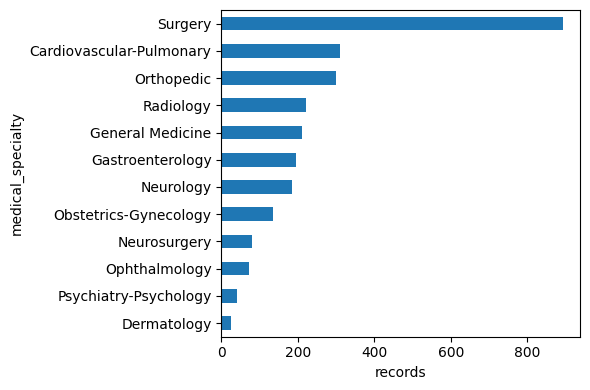

In [7]:
counts = train["medical_specialty"].value_counts()
print(pd.DataFrame({"count": counts, "%": (counts / len(train) * 100).round(1)}))
print(f"\nimbalance ratio (largest / smallest): {counts.max()} / {counts.min()} = {counts.max() / counts.min():.1f}")
print(f"accuracy of always predicting Surgery: {counts.max() / len(train):.1%}")

ax = counts.sort_values().plot.barh(figsize=(6, 4))
ax.set_xlabel("records")
plt.tight_layout()
plt.show()

 Missing values and field length 

In [14]:
def word_counts(col):
    return col.fillna("").str.split().str.len()


summary = pd.DataFrame({
    "missing %": (train[TEXT_COLS].isna().mean() * 100).round(1),
    "median words": [word_counts(train[c]).median() for c in TEXT_COLS],
    "mean words": [round(word_counts(train[c]).mean()) for c in TEXT_COLS],
    "max words": [word_counts(train[c]).max() for c in TEXT_COLS],
})
print(summary)
print("\ntest missing %:", (test[TEXT_COLS].isna().mean() * 100).round(1).to_dict())

               missing %  median words  mean words  max words
description          0.0          16.0          19         76
sample_name          0.3           4.0           4          8
transcription        1.2         386.0         452       2454
keywords            16.9          19.0          23        118

test missing %: {'description': 0.2, 'sample_name': 2.2, 'transcription': 2.7, 'keywords': 20.3}


 Duplicates and label conflicts

The same text often appears more than once with different labels. For each field we count how many texts carry more than
one label, and compute an "oracle" upper bound: the accuracy you would get by predicting, for every text, its most
frequent label in the training set.

In [15]:
def conflict_stats(df, col):
    df = df.dropna(subset=[col])
    labels_by_text = df.groupby(col)["medical_specialty"]
    n_labels = labels_by_text.nunique()
    n_copies = labels_by_text.size()
    conflicting = n_labels[n_labels > 1].index
    best_guess_hits = labels_by_text.apply(lambda s: s.value_counts().iloc[0]).sum()
    return {
        "non-empty": len(df),
        "unique texts": len(n_copies),
        "multi-label texts": len(conflicting),
        "rows affected": int(n_copies[conflicting].sum()),
        "rows affected %": round(n_copies[conflicting].sum() / len(df) * 100, 1),
        "oracle %": round(best_guess_hits / len(df) * 100, 1),
    }


pd.DataFrame({col: conflict_stats(train, col) for col in TEXT_COLS}).T

,non-empty,unique texts,multi-label texts,rows affected,rows affected %,oracle %
description,2668.0,1837.0,736.0,1558.0,58.4,69.6
sample_name,2662.0,1852.0,741.0,1551.0,58.3,69.6
transcription,2638.0,1839.0,730.0,1528.0,57.9,69.7
keywords,2219.0,2216.0,0.0,0.0,0.0,100.0


conflicts

In [16]:
with_text = train.dropna(subset=["transcription"])
labels_of = with_text.groupby("transcription")["medical_specialty"].apply(list)
repeated = labels_of[labels_of.str.len() > 1]

print(repeated.apply(lambda labels: " | ".join(sorted(set(labels)))).value_counts().head(10))

same_label_repeats = sum(len(labels) - len(set(labels)) for labels in repeated)
print("\ntexts that appear more than once:", len(repeated), " repeats with the same label:", same_label_repeats)

medical_specialty
Cardiovascular-Pulmonary | Surgery      123
Orthopedic | Surgery                    122
Gastroenterology | Surgery               97
Obstetrics-Gynecology | Surgery          67
Cardiovascular-Pulmonary | Radiology     44
Ophthalmology | Surgery                  42
Neurology | Radiology                    38
Neurosurgery | Orthopedic | Surgery      26
Orthopedic | Radiology                   22
Neurology | Orthopedic | Radiology       19
Name: count, dtype: int64

texts that appear more than once: 731  repeats with the same label: 1


Overlap between test and training texts

This only looks at the test inputs, no test labels are involved.

In [17]:
# Set of labels seen for each training transcription. Useful later: since a text almost never
# repeats with the same label (2.4), a test copy of a training text most likely has a *different* label.
train_labels_of = labels_of.apply(set)

seen = test["transcription"].isin(train_labels_of.index)
print("test rows with a transcription:", test["transcription"].notna().sum(), " already seen in train:", seen.sum())

seen_labels = test.loc[seen, "transcription"].map(lambda text: " | ".join(sorted(train_labels_of[text])))
print(seen_labels.value_counts().head(12))

test rows with a transcription: 398  already seen in train: 239
transcription
Surgery                      70
Cardiovascular-Pulmonary     27
Orthopedic                   26
Gastroenterology             26
Radiology                    18
Obstetrics-Gynecology        15
Ophthalmology                12
Neurology                     9
Neurology | Neurosurgery      6
Neurosurgery | Orthopedic     5
Neurosurgery | Surgery        5
Neurosurgery                  5
Name: count, dtype: int64


keywords starts with the label
(specialty name itself)

In [18]:
# "Obstetrics-Gynecology" shows up as "obstetrics / gynecology" in keywords
KEYWORD_TO_LABEL = {label.lower().replace("-", " / "): label for label in LABELS}
KEYWORD_TO_LABEL.update({label.lower(): label for label in LABELS})


def label_from_keywords(keywords):
    if pd.isna(keywords):
        return None
    first_term = keywords.split(",")[0].strip().lower()
    return KEYWORD_TO_LABEL.get(first_term)


train_kw = train["keywords"].map(label_from_keywords)
test_kw = test["keywords"].map(label_from_keywords)

has_prefix = train_kw.notna()
print("train rows with keywords:", train["keywords"].notna().sum(),
      " starting with a specialty:", has_prefix.sum(),
      " matching the label:", (train_kw[has_prefix] == train["medical_specialty"][has_prefix]).sum())
print("test rows whose keywords start with a specialty:", test_kw.notna().sum(), "/", len(test))
print("\nshare of each class that has the prefix (train):")
print(train_kw.notna().groupby(train["medical_specialty"]).mean().round(2).sort_values())

train rows with keywords: 2219  starting with a specialty: 2219  matching the label: 2219
test rows whose keywords start with a specialty: 320 / 409

share of each class that has the prefix (train):
medical_specialty
Psychiatry-Psychology       0.34
General Medicine            0.58
Neurology                   0.73
Cardiovascular-Pulmonary    0.74
Dermatology                 0.80
Obstetrics-Gynecology       0.82
Neurosurgery                0.84
Orthopedic                  0.84
Gastroenterology            0.85
Radiology                   0.91
Surgery                     0.93
Ophthalmology               0.96
Name: keywords, dtype: float64


In [20]:
# A few random examples
print(train[["medical_specialty", "keywords"]].dropna().sample(5, random_state=1).to_string(), "\n")

# Three copies of the same report: only the first term differs
same_report = train["description"].str.startswith("Anterior cervical discectomy at C5-6", na=False)
print(train.loc[same_report, ["medical_specialty", "keywords"]].to_string(), "\n")

# Most common terms once the first one is removed
terms = Counter(
    term.strip().lower()
    for keywords in train["keywords"].dropna()
    for term in keywords.split(",")[1:]
    if term.strip()
)
for term, n in terms.most_common(8):
    print(n, term[:80])
print()

# Noise: a website disclaimer, usually glued to the previous word as "...NOTE"
for name, df in [("train", train), ("test", test)]:
    kw = df["keywords"].fillna("")
    n_disclaimer = kw.str.contains("mthelpline", case=False).sum()
    n_glued = kw.str.contains(r"[a-z]NOTE\b").sum()
    print(f"{name}: disclaimer {n_disclaimer}, glued 'xxxNOTE' {n_glued}")

# In 4 broken test rows the keywords ended up in `description`, prefix included
print(test.loc[[18, 242, 325, 358], "description"].str[:60].to_string())

     medical_specialty                                                                                                                                                                                                                                                                                                                                                                                                     keywords
1969           Surgery                                                                                                                                                                                                                                                                                                surgery, serous drainage, bilateral pleural effusion, pleural effusion, chest tubes, effusion, pleural, chest
1620         Radiology                                                                                                                                          

Cleaning the keyword

Remove a leading specialty.

In keywords, cut everything from NOTE onwards (the disclaimer)


In [22]:
LABEL_PREFIX = re.compile(r"^\s*(" + "|".join(map(re.escape, KEYWORD_TO_LABEL)) + r")\s*,\s*", re.IGNORECASE)
DISCLAIMER = re.compile(r"NOTE\b.*$", re.DOTALL)


def clean_field(text, col):
    if pd.isna(text):
        return text
    text = LABEL_PREFIX.sub("", text)
    if col == "keywords":
        text = DISCLAIMER.sub("", text)
    text = text.strip().rstrip(",").strip()
    return text or pd.NA


def clean(df):
    df = df.copy()
    for col in TEXT_COLS:
        df[col] = df[col].map(lambda text: clean_field(text, col))
    return df


train_clean = clean(train)
test_clean = clean(test)

In [23]:
for name, df in [("train", train_clean), ("test", test_clean)]:
    fields = df[TEXT_COLS].fillna("")
    print(name, df.shape,
          " label prefix:", fields.apply(lambda col: col.str.match(LABEL_PREFIX)).sum().sum(),
          " disclaimer:", fields.apply(lambda col: col.str.contains("mthelpline", case=False)).sum().sum(),
          " NOTE:", fields["keywords"].str.contains("NOTE").sum())

# Copies of the same report should now have identical keywords, so conflicts appear here too
print(pd.DataFrame({col: conflict_stats(train_clean, col) for col in ["transcription", "keywords"]}).T)

print("\nbefore:", train.at[985, "keywords"])
print("after: ", train_clean.at[985, "keywords"])

train (2669, 5)  label prefix: 0  disclaimer: 0  NOTE: 0
test (409, 4)  label prefix: 0  disclaimer: 0  NOTE: 0
               non-empty  unique texts  multi-label texts  rows affected  rows affected %  oracle %
transcription     2638.0        1839.0              730.0         1528.0             57.9      69.7
keywords          2214.0        1501.0              650.0         1361.0             61.5      67.9

before: neurosurgery, herniated nucleus pulposus, anterior cervical discectomy, artificial disk replacement, cervical, discectomy, nucleusNOTE
after:  herniated nucleus pulposus, anterior cervical discectomy, artificial disk replacement, cervical, discectomy, nucleus
